# Task 3: Play Tennis Prediction
### Predict if someone will play tennis based on weather conditions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings("ignore")


In [3]:
np.random.seed(42)
outlook_opts = ["Sunny","Overcast","Rainy"]
temp_opts = ["Hot","Mild","Cool"]
humidity_opts = ["High","Normal"]
wind_opts = ["Weak","Strong"]

data = {
    "outlook":    ["Sunny","Sunny","Overcast","Rainy","Rainy","Rainy","Overcast","Sunny","Sunny","Rainy",
                   "Sunny","Overcast","Overcast","Rainy","Sunny","Rainy","Overcast","Sunny","Rainy","Overcast"],
    "temperature":["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool","Mild",
                   "Mild","Mild","Hot","Mild","Mild","Cool","Cool","Mild","Mild","Hot"],
    "humidity":   ["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal",
                   "Normal","High","Normal","High","Normal","Normal","High","High","Normal","Normal"],
    "wind":       ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak",
                   "Strong","Strong","Weak","Strong","Strong","Weak","Weak","Strong","Weak","Strong"],
    "play":       ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes",
                   "Yes","Yes","Yes","No","No","Yes","Yes","No","Yes","Yes"]
}
df = pd.DataFrame(data)
print(df)
print("\nPlay Distribution:")
print(df["play"].value_counts())


     outlook temperature humidity    wind play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3      Rainy        Mild     High    Weak  Yes
4      Rainy        Cool   Normal    Weak  Yes
5      Rainy        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9      Rainy        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13     Rainy        Mild     High  Strong   No
14     Sunny        Mild   Normal  Strong   No
15     Rainy        Cool   Normal    Weak  Yes
16  Overcast        Cool     High    Weak  Yes
17     Sunny        Mild     High  Strong   No
18     Rainy        Mild   Normal    Weak  Yes
19  Overcast         Hot   Normal  Strong  Yes

Play Distrib

In [5]:
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop("play", axis=1)
y = df_enc["play"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)



from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No","Yes"]))

 Accuracy: 80.0 %

 Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



In [ ]:
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop("play", axis=1)
y = df_enc["play"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No","Yes"]))


✅ Accuracy: 80.0 %

📊 Classification Report:
              precision    recall  f1-score   support

          No       0.75      1.00      0.86         3
         Yes       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



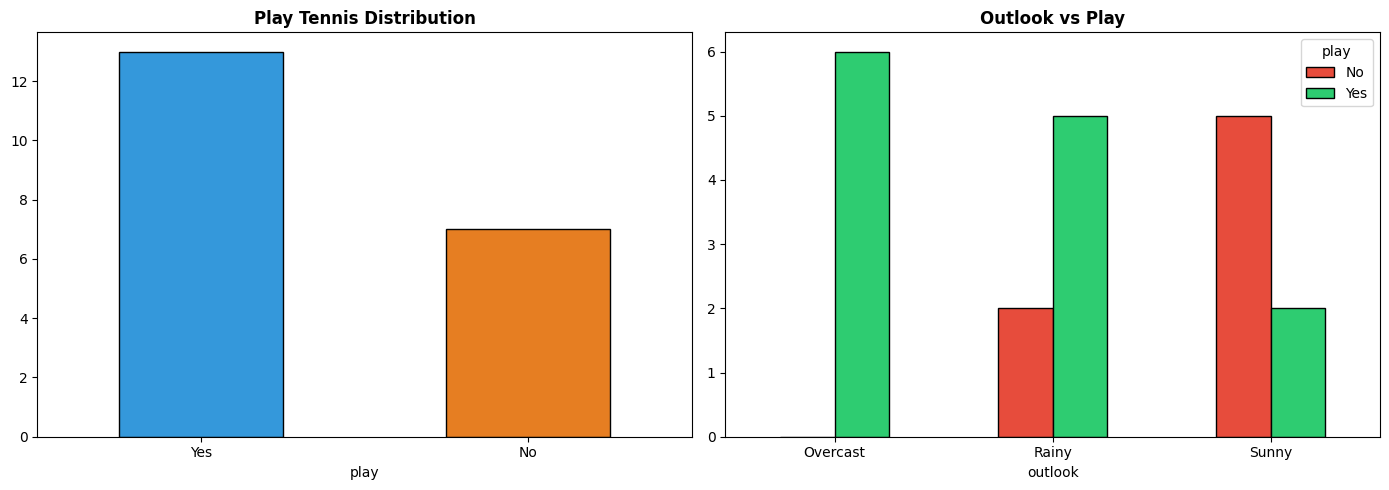

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["play"].value_counts().plot(kind="bar", ax=axes[0], color=["#3498db","#e67e22"], edgecolor="black")
axes[0].set_title("Play Tennis Distribution", fontweight="bold"); axes[0].tick_params(rotation=0)

pd.crosstab(df["outlook"], df["play"]).plot(kind="bar", ax=axes[1], color=["#e74c3c","#2ecc71"], edgecolor="black")
axes[1].set_title("Outlook vs Play", fontweight="bold"); axes[1].tick_params(rotation=0)
plt.tight_layout(); plt.savefig("task3_viz.png", dpi=100); plt.show()


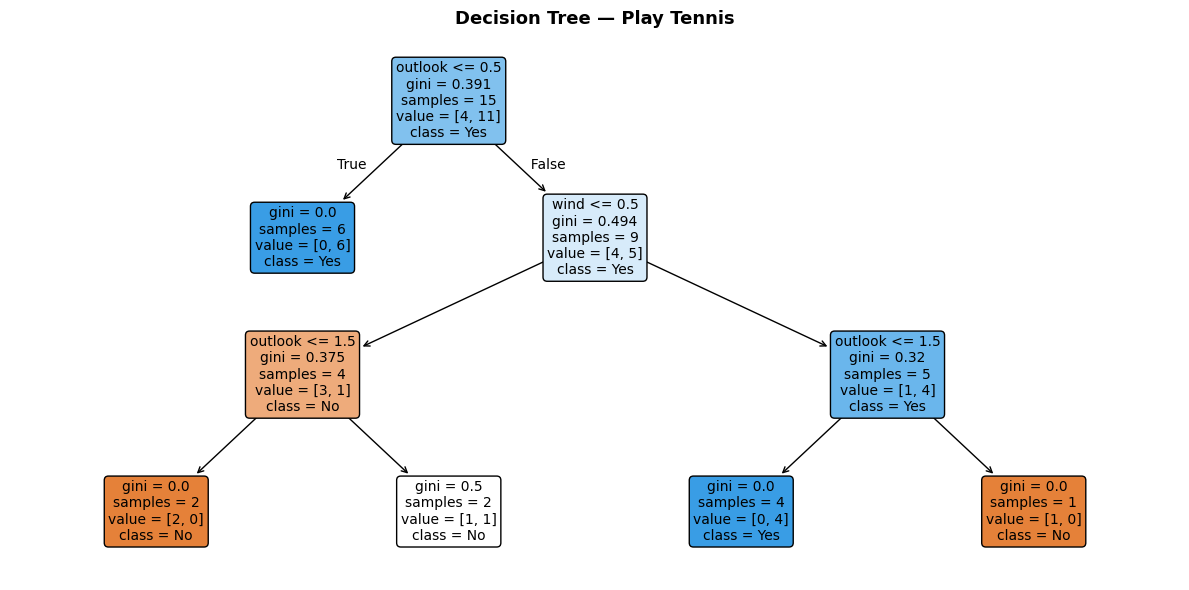

In [5]:
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, class_names=["No","Yes"], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — Play Tennis", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig("task3_tree.png", dpi=100); plt.show()
